# Data simulation

This notebook evaluates the thesis methods in controlled simulated data-generating processes (DGPs). It generates four dependence structures, compares distribution-forecasting approaches, evaluates failure-risk prediction, and summarizes performance across Monte Carlo replications.

The simulation is self-contained: it does not require the empirical source data. Randomness is controlled by the `SEED` configuration below.

Fella Bouznad, 30/09/2026 \
MPhil Thesis Business Data Science - Operations Analytics

In [ ]:
from itertools import combinations
from pathlib import Path
import warnings

from IPython.display import display
from joblib import Parallel, delayed
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
from scipy.integrate import cumulative_trapezoid, trapezoid
from scipy.special import expit
from scipy.stats import norm, gaussian_kde, kurtosis
from sklearn.metrics import (
    auc,
    brier_score_loss,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

In [ ]:
SEED = 41
T = 6
N = 13221
YEARS = np.arange(T)
DGP_LIST = (1,2,3,4)
NU = 5 #student-t degrees of freedom in DGP3
CLAYTON_THETA = 0.75 #clayton dependence parameter in DGP4
TARGET_FAILURE_RATE = 0.04
MC_REPS = 50

MU_ROA = 0.04
BETA_ALPHA_ROA = 0.025
BETA_MACRO_ROA = 0.020
SIGMA_ROA = 0.040

MU_LEV = 0.60
GAMMA_ALPHA_LEV = 0.060
GAMMA_ROA_LEV = 0.70
SIGMA_LEV = 0.080

MU_LIQ = 1.40
ETA_ROA_LIQ = 1.00
ETA_LEV_LIQ = 0.80
SIGMA_LIQ = 0.20

MU_EQ = 0.40
DELTA_LEV_EQ = 0.70
SIGMA_EQ = 0.080

MU_SIZE = 17.0
THETA_ALPHA_SIZE = 0.60
THETA_TIME_SIZE = 0.05
SIGMA_SIZE = 0.50

KAPPA_FDI = 1.50
KAPPA_ALPHA = 0.25
KAPPA_MACRO = 0.15

SIGMA_DGP2 = np.array([
    [ 1.0, -0.5,  0.4,  0.4],
    [-0.5,  1.0, -0.4, -0.5],
    [ 0.4, -0.4,  1.0,  0.4],
    [ 0.4, -0.5,  0.4,  1.0]
]) #positive-definite covariance matrix for DGP2.

DIST_TAUS = np.array([0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95])
DENSITY_X_GRID_SIZE = 201
EPS = 1e-7
LQD_S_GRID = np.linspace(0.01, 0.99, 199)
FPCA_VAR_TARGET = 0.95
FIN_COLS = [
    'roa',
    'lev',
    'current_ratio',
    'equity_ratio'
]
PRED_TEST_SIZE = 0.20

CONTROL_CONT = [
    'size',
    'subsidiaries'
]

CONTROL_BINARY = [
    'big4',
    'PIE_entity'
]

INDUSTRY_LEVELS = [
    'Manufacturing',
    'Retail',
    'Finance',
    'Services'
]
YEAR_LEVELS = list(YEARS)
RANK_TAUS = np.round(np.arange(0.05, 1.00, 0.05), 2)

plasma = plt.cm.plasma
COLOR_OBSERVED   = plasma(0.08)   #dark purple
COLOR_QUANTILE   = plasma(0.48)   #magenta/orange
COLOR_FUNCTIONAL = plasma(0.88)   #yellow-orange
DGP_COLORS = {
    'DGP1': plasma(0.12),
    'DGP2': plasma(0.38),
    'DGP3': plasma(0.64),
    'DGP4': plasma(0.88)
}
DGP_TITLES = {
    'DGP1': 'DGP1: Independent Gaussian',
    'DGP2': 'DGP2: Correlated Gaussian',
    'DGP3': 'DGP3: Heavy-tailed Student-t',
    'DGP4': 'DGP4: Clayton tail dependence'
}

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
FIGURE_DIR = PROJECT_ROOT / 'results' / 'simulation'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## Simulated data-generating processes

Generate four DGPs that share firm heterogeneity and macro conditions but differ in the dependence and tail behavior of the financial disturbances. The resulting panels contain financial variables, the simulated Financial Distress Index (FDI), and failure outcomes calibrated to the target failure rate.

In [ ]:
#functions
def gaussian_copula(n, rho, rng):
    cov = [[1,rho],[rho,1]]
    z = rng.multivariate_normal(mean=[0,0], cov=cov, size=n)
    u_gaussian = norm.cdf(z[:, 0])
    v_gaussian = norm.cdf(z[:, 1])
    return u_gaussian, v_gaussian

def clayton_copula(n, theta, rng):
    w = rng.gamma(shape=1/theta, scale=1.0, size=n)
    E_1 = rng.exponential(size=n)
    E_2 = rng.exponential(size=n)
    u_clayton = (1+E_1/w)**(-1/theta)
    v_clayton = (1+E_2/w)**(-1/theta)
    return u_clayton, v_clayton

def copula_comparison3D(u_gaussian, v_gaussian, u_clayton, v_clayton, grid_size = 60):
    xgrid = np.linspace(0.001, 0.999, grid_size)
    ygrid = np.linspace(0.001, 0.999, grid_size)
    X, Y = np.meshgrid(xgrid, ygrid)
    positions = np.vstack([X.ravel(), Y.ravel()])

    #gaussian KDE
    values_gauss = np.vstack([u_gaussian, v_gaussian])
    kernel_gauss = gaussian_kde(values_gauss)
    Z_gauss = np.reshape(kernel_gauss(positions).T, X.shape)

    #clayton KDE
    values_clayton = np.vstack([u_clayton, v_clayton])
    kernel_clayton = gaussian_kde(values_clayton)
    Z_clayton = np.reshape(kernel_clayton(positions).T, X.shape)

    fig = plt.figure(figsize=(14, 6))

    #gaussian copula
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot_surface(X, Y, Z_gauss, cmap='plasma', edgecolor='none')
    ax1.set_title('Gaussian Copula')
    ax1.set_xlabel(r'$u_1$')
    ax1.set_ylabel(r'$u_2$')
    ax1.set_zlabel('Density')

    #clayton Copula Surface
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot_surface(X, Y, Z_clayton, cmap='plasma', edgecolor='none')
    ax2.set_title(r'Clayton Copula ($\theta = 0.75$)')
    ax2.set_xlabel(r'$u_1$')
    ax2.set_ylabel(r'$u_2$')
    ax2.set_zlabel('Density')

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'copula_3d_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_copulas(seed=SEED):
    n = 5000
    rho = 0.7
    theta = 0.75
    rng = np.random.default_rng(seed)
    u_gaussian, v_gaussian = gaussian_copula(n, rho, rng)
    u_clayton, v_clayton = clayton_copula(n, theta, rng)
    copula_comparison3D(u_gaussian, v_gaussian, u_clayton, v_clayton)

def generate_firm_heterogeneity(n_firms, rng):
    alpha = rng.normal(loc=0.0,scale=1.0,size=n_firms) #N(0,1) multivariate
    return alpha

def generate_macro_process(T, rng, phi_macro = 0.60, sigma_u = 0.50):
    lambda_t = np.zeros(T)
    for tt in range(1,T):
        u_t = rng.normal(loc=0.0, scale = sigma_u)
        lambda_t[tt] = (phi_macro * lambda_t[tt-1] + u_t)
    return lambda_t

def generate_firm_characteristics(firm_ids, rng):
    n_firms = len(firm_ids)
    return pd.DataFrame({
        'firm_id': firm_ids,
        'industry': rng.choice(['Manufacturing', 'Retail', 'Finance', 'Services'], size=n_firms),
        'big4': rng.binomial(n=1,p=0.35,size=n_firms),
        'PIE_entity': rng.binomial(n=1,p=0.10, size=n_firms),
        'subsidiaries': rng.poisson(lam=3, size=n_firms)
    })

def clayton_copula_sim(n, rng, dim=4, theta=CLAYTON_THETA):
    W = rng.gamma(shape=1/theta, scale=1.0, size=n)
    E = rng.exponential(scale=1.0, size=(n,dim))
    U = (1+E/W[:,None])**(-1/theta)
    return U

def draw_financial_disturbances(dgp, n_observations, rng):
    if dgp==1:
        epsilon = rng.normal(loc=0.0, scale=1.0, size=(n_observations,4))
    elif dgp==2:
        epsilon = rng.multivariate_normal(mean=np.zeros(4), cov=SIGMA_DGP2, size=n_observations)
    elif dgp==3:
        epsilon_raw = rng.standard_t(df=NU, size=(n_observations,4))
        epsilon = (epsilon_raw*np.sqrt((NU-2)/NU)) 
    else:
        U = clayton_copula_sim(n=n_observations, rng=rng, dim=4, theta=CLAYTON_THETA)
        U = np.clip(U, 1e-10, 1 - 1e-10) #no inf
        q = norm.ppf(U)
        epsilon = np.column_stack([q[:,0], -q[:,1], q[:,2], q[:,3]]) #high leverage, low roa, liq, equity ratio

    return epsilon

def generate_financial_panel(dgp, alpha, lambda_t, rng):
    n_firms = len(alpha)
    n_observations = (n_firms*T)
    firm_id = np.repeat(np.arange(n_firms), T)
    year = np.tile(YEARS, n_firms)
    alpha_it = alpha[firm_id]
    lambda_it = lambda_t[year]
    epsilon = draw_financial_disturbances(dgp=dgp, n_observations=n_observations, rng=rng)
    (e_roa, e_lev, e_liq, e_eq) = epsilon.T
    
    roa = (MU_ROA + BETA_ALPHA_ROA*alpha_it + BETA_MACRO_ROA*lambda_it + SIGMA_ROA*e_roa)

    leverage_raw = (MU_LEV + GAMMA_ALPHA_LEV*alpha_it - GAMMA_ROA_LEV*(roa-MU_ROA) + SIGMA_LEV*e_lev)
    leverage = np.maximum(leverage_raw, 0.0) #ensure non-negativity

    current_ratio_raw = (MU_LIQ + ETA_ROA_LIQ*(roa - MU_ROA) - ETA_LEV_LIQ * (leverage- MU_LEV ) + SIGMA_LIQ *e_liq)
    current_ratio = np.maximum(current_ratio_raw, 0.05) #ensure positivity

    equity_ratio = (MU_EQ - DELTA_LEV_EQ * (leverage - MU_LEV) + SIGMA_EQ * e_eq)

    size = (MU_SIZE + THETA_ALPHA_SIZE*alpha_it + THETA_TIME_SIZE * year + rng.normal(loc=0.0, scale=SIGMA_SIZE, size=n_observations))

    return pd.DataFrame({
        'firm_id': firm_id,
        'year': year,
        'alpha_i': alpha_it,
        'lambda_t': lambda_it,
        'roa': roa,
        'lev': leverage,
        'current_ratio': current_ratio,
        'equity_ratio': equity_ratio,
        'size': size,
        'lev_bounded': leverage_raw <0,
        'liquidity_bounded': current_ratio_raw < 0.05
    })

def within_year_zscore(df, variable):
    yearly_mean = (df.groupby('year')[variable].transform('mean'))
    yearly_sd = (df.groupby('year')[variable].transform('std').replace(0,np.nan)) #no inf
    sd_variable = (df[variable] - yearly_mean) / yearly_sd #standardize
    return sd_variable

def add_fdi(df):
    df = df.copy()
    df['z_roa'] = (within_year_zscore(df,'roa'))
    df['z_lev'] = (within_year_zscore(df,'lev'))
    df['z_liquidity'] = (within_year_zscore(df,'current_ratio'))
    df['z_equity'] = (within_year_zscore(df,'equity_ratio'))

    df['profitability_distress_z'] = (-df['z_roa'])
    df['leverage_distress_z'] = (df['z_lev'])
    df['liquidity_distress_z'] = (-df['z_liquidity'])
    df['equity_distress_z'] = (-df['z_equity'])

    distress_columns = ['profitability_distress_z', 'leverage_distress_z', 'liquidity_distress_z', 'equity_distress_z']
    df['FDI'] = (df[distress_columns].mean(axis=1))
    return df

def calibrate_failure_intercept(linear_predictor, target_rate = TARGET_FAILURE_RATE):
    linear_predictor = np.asarray(linear_predictor)
    lower = -20.0
    upper = 5.0
    for _ in range(100):
        midpoint = (lower+upper)/2
        mean_probability = (expit(midpoint + linear_predictor).mean())
        if (mean_probability > target_rate):
            upper = midpoint 
        else:
            lower = midpoint

    kappa_0 = (lower + upper)/2
    return kappa_0

def add_failure(df, rng, target_rate = TARGET_FAILURE_RATE):
    df = df.copy()
    linear_predictor = (KAPPA_FDI*df['FDI'] + KAPPA_ALPHA*df['alpha_i'] + KAPPA_MACRO * df['lambda_t'])
    kappa_0 = (calibrate_failure_intercept(linear_predictor = linear_predictor, target_rate = target_rate))
    df['failure_prob'] = (expit(kappa_0 + linear_predictor))
    df['failure_event'] = (rng.binomial(n=1, p=df['failure_prob'].to_numpy()))
    df['ever_failure'] = (df.groupby('firm_id')['failure_event'].transform('max').astype(int))
    df['failure_intercept'] = (kappa_0) 
    return df

def create_simulated_dgp(dgp, alpha, lambda_t, firm_characteristics, rng, target_failure_rate = TARGET_FAILURE_RATE):
    df = generate_financial_panel(dgp=dgp, alpha=alpha, lambda_t=lambda_t, rng=rng) #financial variables
    df = add_fdi(df) #fdi
    df = add_failure(df, rng=rng, target_rate=target_failure_rate)  # failure
    df = df.merge(firm_characteristics, on='firm_id', how='left', validate='many_to_one')
    df['DGP'] = (f'DGP{dgp}')
    return df

def generate_all_dgps_once(seed = SEED, n_firms = N, target_failure_rate = TARGET_FAILURE_RATE):
    shared_rng = (np.random.default_rng(seed))
    firm_ids = np.arange(n_firms)
    alpha = (generate_firm_heterogeneity(n_firms = n_firms, rng=shared_rng))
    lambda_t = (generate_macro_process(T=T, rng=shared_rng))
    firm_characteristics = (generate_firm_characteristics(firm_ids=firm_ids, rng=shared_rng))
    datasets = {}

    for dgp in DGP_LIST:
        dgp_rng = (np.random.default_rng(seed + 1000 * dgp))
        datasets[f'DGP{dgp}'] = create_simulated_dgp(dgp=dgp, 
                                                     alpha=alpha, 
                                                     lambda_t=lambda_t, 
                                                     firm_characteristics = firm_characteristics, 
                                                     rng=dgp_rng, 
                                                     target_failure_rate=target_failure_rate)
    return (datasets, alpha, lambda_t, firm_characteristics)

def run_monte_carlo(n_replications, base_seed = SEED, n_firms = N):
    for replication in range(n_replications):
        replication_seed = (base_seed + 100000 * replication)
        (datasets, alpha, lambda_t, firm_characteristics) = generate_all_dgps_once(
            seed = replication_seed, n_firms = n_firms, target_failure_rate = TARGET_FAILURE_RATE)
        yield replication, datasets 

def test_monte_carlo(n_replications):
    rows = [] #create dictionary
    for replication, datasets in run_monte_carlo(n_replications = n_replications):
        for name, df in datasets.items():
            roa_q10 = df['roa'].quantile(0.10)
            lev_q90 = df['lev'].quantile(0.90)
            liq_q10 = df['current_ratio'].quantile(0.10)
            eq_q10 = df['equity_ratio'].quantile(0.10)
            adverse = np.column_stack([df['roa'].to_numpy() <= roa_q10,
                                      df['lev'].to_numpy() >= lev_q90,
                                      df['current_ratio'].to_numpy() <= liq_q10,
                                    df['equity_ratio'].to_numpy() <= eq_q10])
            adverse_count = (adverse.sum(axis=1))
        
            rows.append({
                'replication': replication,
                'DGP': name,
                'failure_rate': df['failure_event'].mean(),
                'expected_failure_rate': df['failure_prob'].mean(),
                'roa_mean': df['roa'].mean(),
                'lev_mean': df['lev'].mean(),
                'liquidity_mean': df['current_ratio'].mean(),
                'equity_mean': df['equity_ratio'].mean(),
                'FDI_mean': df['FDI'].mean(),
                'FDI_sd': df['FDI'].std(),
                'ROA_kurtosis': kurtosis(df['roa'],fisher=False, bias=False),
                'FDI_kurtosis': kurtosis(df['FDI'],fisher=False, bias=False),
                'share_3plus_adverse': (adverse_count >= 3).mean(), 
                'leverage_bound_share': df['lev_bounded'].mean(),
                'liquidity_bound_share': df['liquidity_bounded'].mean()
            })
    
    return pd.DataFrame(rows)

def summarize_mc_dgps(mc_dgp_results):
    summary = (mc_dgp_results.groupby('DGP').agg(
        failure_rate_mean=('failure_rate', 'mean'),
        failure_rate_sd=('failure_rate', 'std'),
        expected_failure_rate_mean=('expected_failure_rate','mean'),
        roa_mean=('roa_mean', 'mean'),
        leverage_mean=('lev_mean', 'mean'),
        liquidity_mean = ('liquidity_mean', 'mean'),
        equity_mean = ('equity_mean', 'mean'),
        FDI_mean = ('FDI_mean', 'mean'),
        FDI_sd_mean = ('FDI_sd', 'mean'),
        ROA_kurtosis_mean = ('ROA_kurtosis', 'mean'),
        FDI_kurtosis_mean = ('FDI_kurtosis', 'mean'),
        joint_adverse_share_mean=('share_3plus_adverse', 'mean'),
        leverage_bound_share_mean = ('leverage_bound_share', 'mean'),
        liquidity_bound_share_mean = ('liquidity_bound_share', 'mean')
    ))
    return summary

def plot_simulations(all_datasets, save_path=None): 
    if save_path is None:
        save_path = FIGURE_DIR / 'four_simulations_all_pairs.png'

    variables = ['roa', 'lev', 'current_ratio', 'equity_ratio']
    pairs = list(combinations(variables, 2))
    dgp_keys = ['DGP1', 'DGP2', 'DGP3', 'DGP4']
    dgp_titles = {
        'DGP1': 'DGP1: Independent Gaussian', 
        'DGP2': 'DGP2: Correlated Gaussian',
        'DGP3': 'DGP3: Heavy-tailed Student-t', 
        'DGP4': 'DGP4: Clayton tail dependence'}

    variable_labels = {
        'roa': 'Return on Assets',
        'lev': 'Leverage',
        'current_ratio': 'Current Ratio',
        'equity_ratio': 'Equity Ratio'
    }

    axis_limits = {}
    for xvar, yvar in pairs:
        x_all = pd.concat([all_datasets[dgp][xvar] for dgp in dgp_keys], ignore_index=True)
        y_all = pd.concat([all_datasets[dgp][yvar] for dgp in dgp_keys], ignore_index=True)
        x_low = x_all.quantile(0.005)
        x_high = x_all.quantile(0.995)
        y_low = y_all.quantile(0.005)
        y_high = y_all.quantile(0.995)
        axis_limits[(xvar, yvar)] = (x_low,x_high,y_low,y_high)

    n_rows = len(pairs)
    n_cols = len(dgp_keys)
    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(18, 20),
        sharex=False,
        sharey=False
    )
    for col, dgp_key in enumerate(dgp_keys):
        df = (all_datasets[dgp_key].copy())
        
        plot_df = df
        for row, (xvar,yvar) in enumerate(pairs):
            ax=axes[row,col]
            ax.scatter(plot_df[xvar], plot_df[yvar],c=plot_df[xvar],cmap='plasma', s=5,alpha=0.3)
            (x_low,x_high,y_low,y_high) = axis_limits[(xvar,yvar)]
            ax.set_xlim(x_low,x_high)
            ax.set_ylim(y_low,y_high)
            ax.set_xlabel(variable_labels[xvar])
            ax.set_ylabel(variable_labels[yvar])
            if row==0:
                ax.set_title(dgp_titles[dgp_key],fontsize=12,fontweight='bold')
    
    fig.suptitle(
        'Joint Financial-Variable Distributions Across Simulated DGPs',
        fontsize=15,
        y=1.005
    )
    plt.tight_layout()
    plt.savefig(save_path,dpi=300,bbox_inches='tight')
    plt.show()

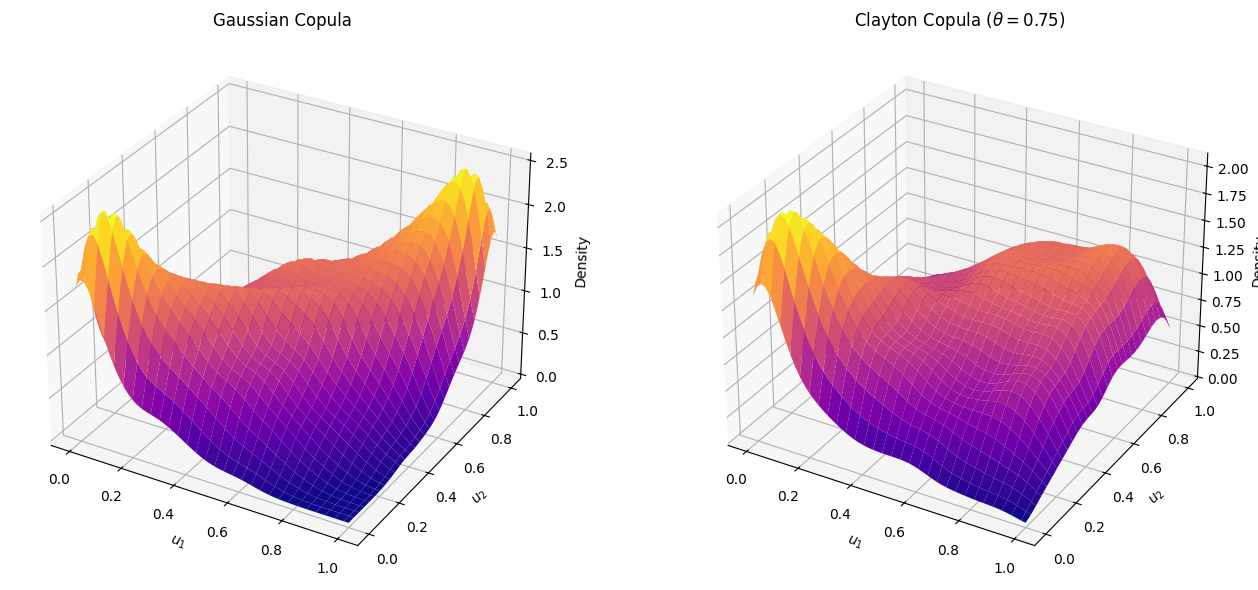

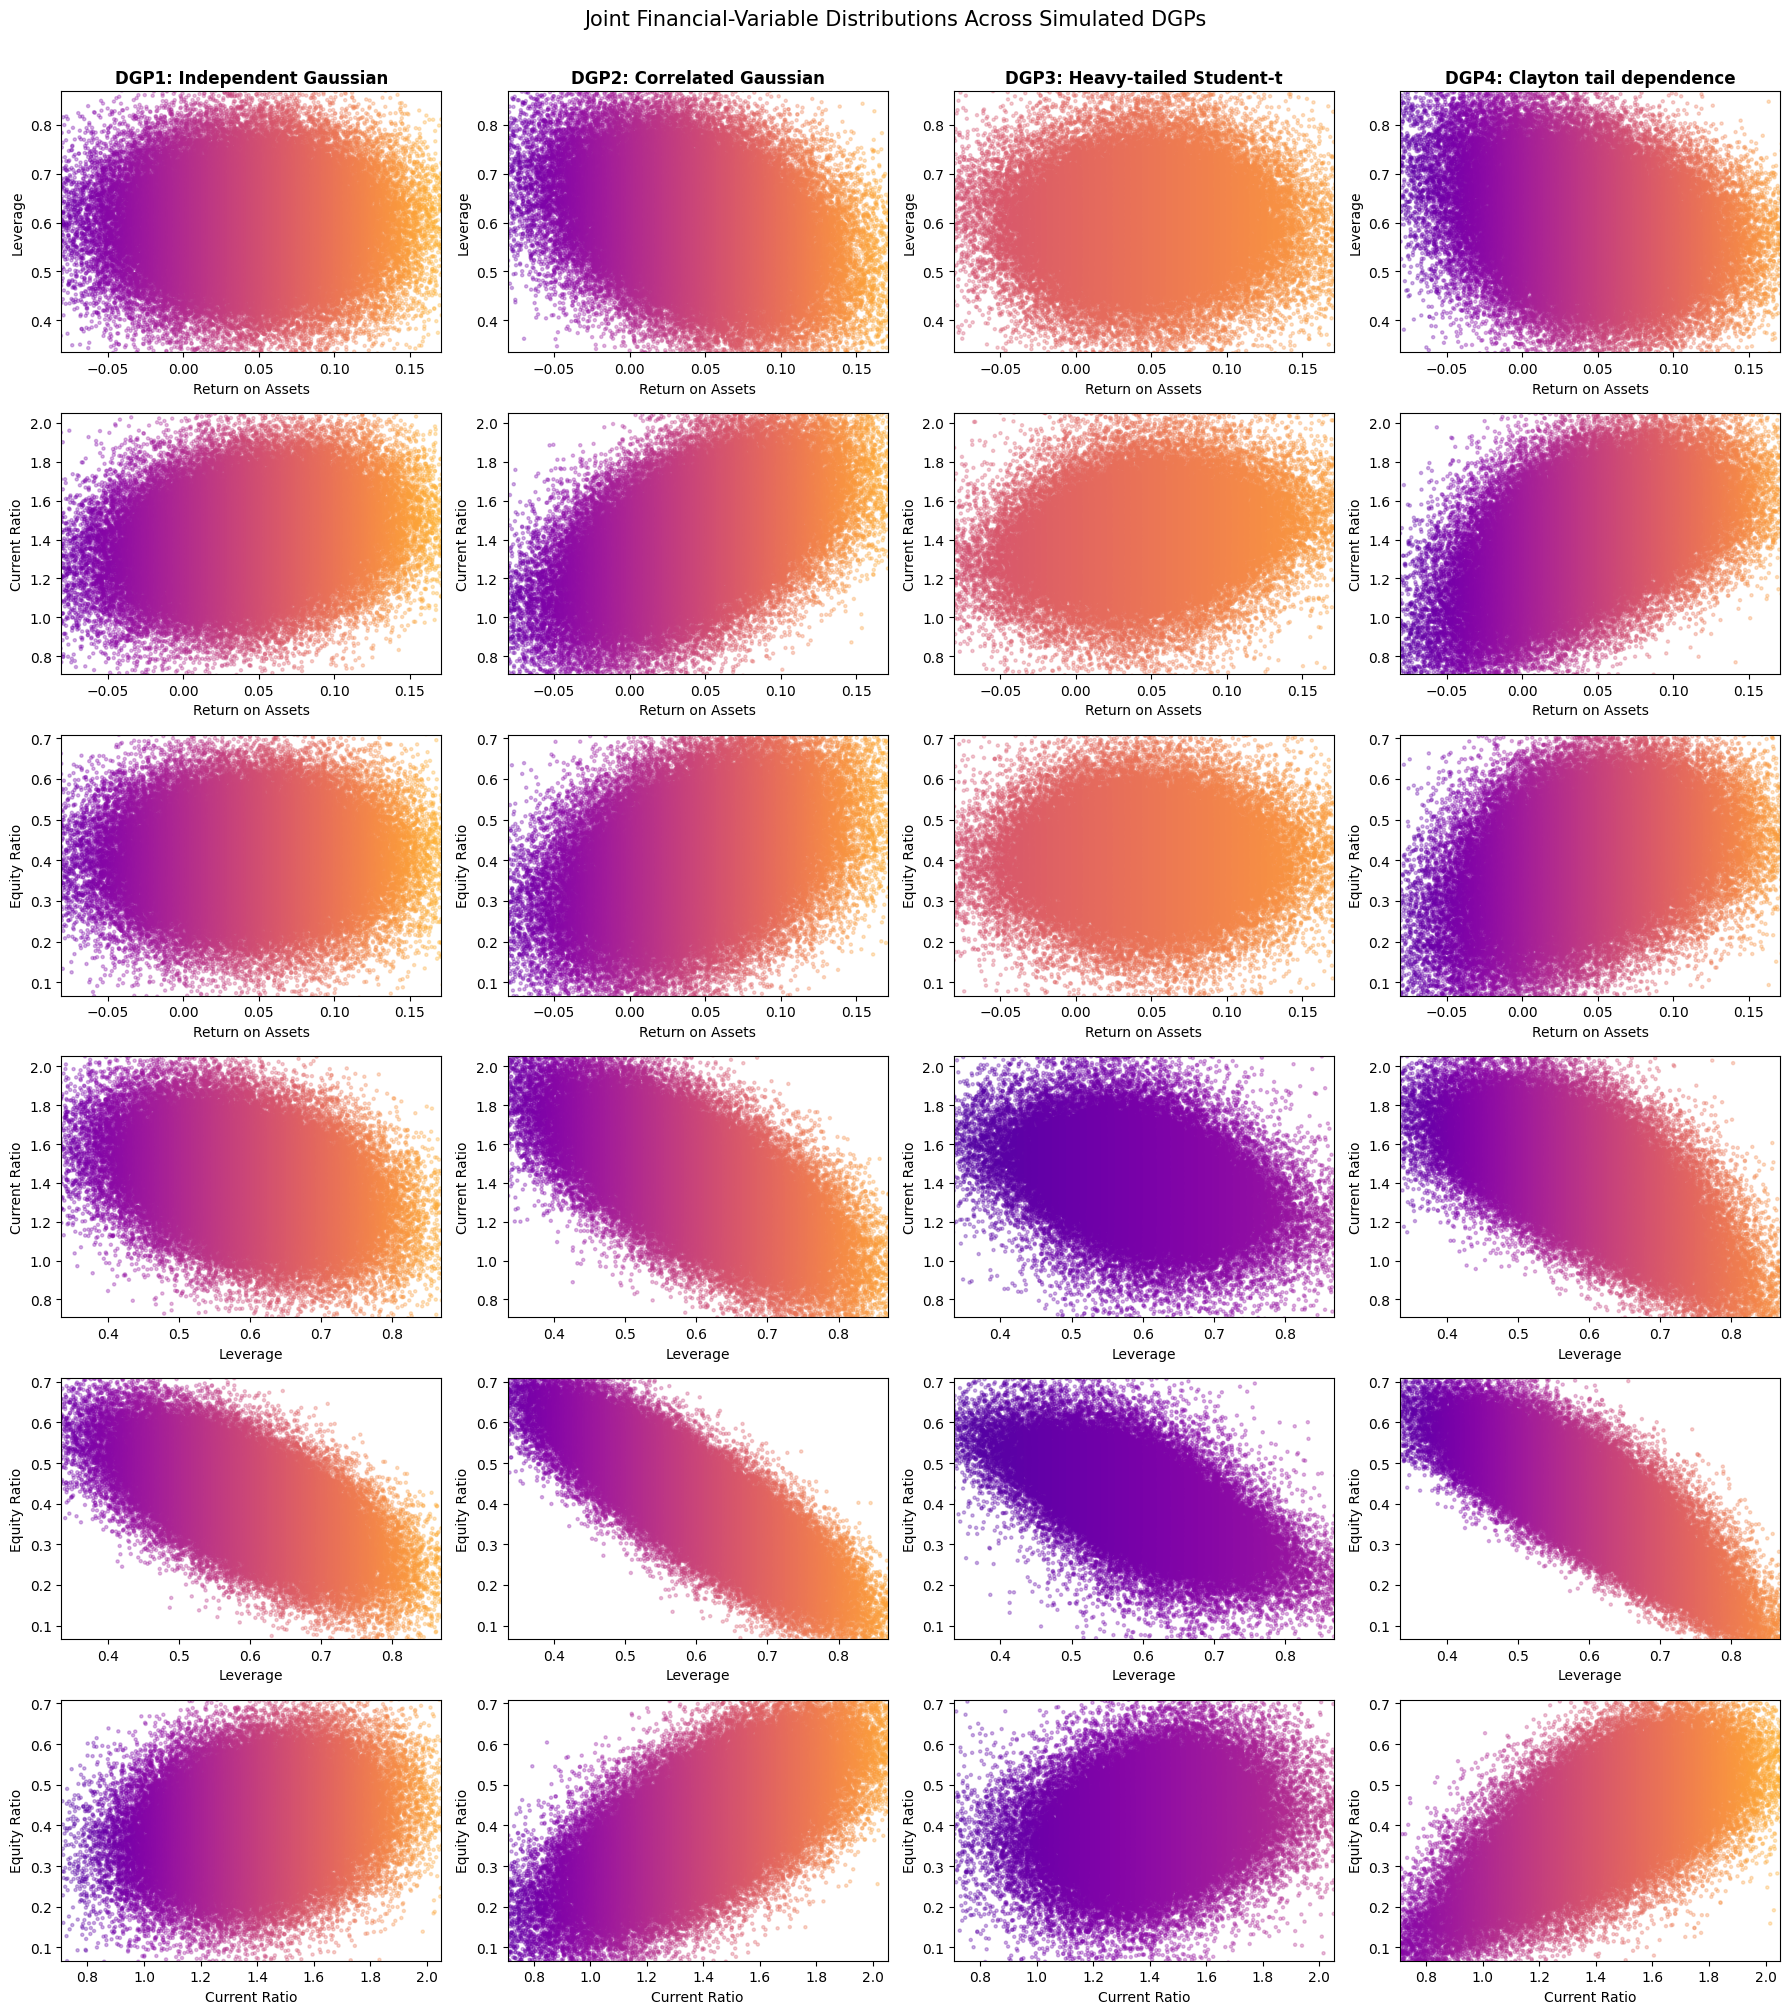

     replication   DGP  failure_rate  expected_failure_rate  roa_mean  \
0              0  DGP1      0.040088                   0.04  0.045013   
1              0  DGP2      0.038562                   0.04  0.045078   
2              0  DGP3      0.039571                   0.04  0.044915   
3              0  DGP4      0.040529                   0.04  0.045032   
4              1  DGP1      0.040466                   0.04  0.038005   
..           ...   ...           ...                    ...       ...   
195           48  DGP4      0.038751                   0.04  0.043464   
196           49  DGP1      0.040655                   0.04  0.028930   
197           49  DGP2      0.040214                   0.04  0.028704   
198           49  DGP3      0.040718                   0.04  0.028707   
199           49  DGP4      0.039609                   0.04  0.028692   

     lev_mean  liquidity_mean  equity_mean      FDI_mean    FDI_sd  \
0    0.596224        1.407361     0.402976  1.280887e

In [ ]:
plot_copulas()
all_datasets, alpha, lambda_t, firm_characteristics = (generate_all_dgps_once(
        seed=SEED,
        n_firms=N,
        target_failure_rate=TARGET_FAILURE_RATE
    ))
plot_simulations(all_datasets)
mc_dgps = test_monte_carlo(n_replications=MC_REPS)
mc_summary = summarize_mc_dgps(mc_dgps)
print(mc_summary.round(4))

## Financial-distress distribution forecasting

Forecast the held-out FDI distribution in the final simulated period. The notebook compares a conditional-quantile benchmark with the functional distribution-forecasting approach using common distributional scoring metrics.

In [ ]:
def training_support(y, padding=0.05):
    y = np.asarray(y, dtype=float)
    l = float(np.nanmin(y))
    u = float(np.nanmax(y))
    span = max(u - l, 1e-7)
    
    lower = l - padding*span #needed for functional
    upper = u + padding*span
    return (lower, upper)
    
def make_strictly_increasing(x, eps=1e-7):
    x = np.asarray(x, dtype=float).copy()

    scale = max(float(np.nanstd(x)), 1.0)
    min_step = eps*scale

    for j in range(1, len(x)):
        if x[j]<=x[j-1]:
            x[j]=x[j-1] + min_step #such that inverse exists
    return x
    

### Benchmark: conditional quantiles

Fit quantile regressions over time and use the estimated held-out quantiles as the benchmark forecast distribution.

In [ ]:
def fit_quantile(df):
    target_t = int(df['year'].max())
    train = (df.loc[df['year']<target_t].copy())
    X_train = sm.add_constant(train[['year']].astype(float), has_constant='add')
    y_train = train['FDI'].to_numpy()

    forecast_quantiles = []
    iteration_counts = []
    for tau in DIST_TAUS:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            model = sm.QuantReg(y_train, X_train) #equation (27)
            fit = model.fit(q=float(tau), max_iter=3000, p_tol = 1e-7)
        X_target = pd.DataFrame({'const': [1.0], 'year': [float(target_t)]})
        q_forecast = float(fit.predict(X_target).iloc[0])
        forecast_quantiles.append(q_forecast)
        iteration_counts.append(int(fit.iterations))
        
    forecast_quantiles = np.asarray(forecast_quantiles)
    forecast_quantiles = np.sort(forecast_quantiles)

    taus = np.r_[0.0, DIST_TAUS, 1.0]

    lower, upper = training_support(y_train, padding=0.05)
    q_values = np.r_[lower, forecast_quantiles, upper]
    q_values = np.maximum.accumulate(q_values)
    q_values = make_strictly_increasing(q_values)

    model = {
        'taus': taus,
        'qvals': q_values,
        'reported_quantiles': dict(zip(DIST_TAUS, forecast_quantiles)),
        'max_qr_iterations': max(iteration_counts)
    }
    return model

### Functional approach

Represent the evolving FDI distribution through the functional transformation used in the thesis and forecast the held-out distribution from its estimated temporal dynamics.

In [ ]:
def linear_forecast(values, times, target_t):
    values = np.asarray(values, dtype=float)
    times = np.asarray(times, dtype=float)
    X = np.column_stack([np.ones(len(times)), times])
    coef = np.linalg.lstsq(X, values, rcond=None)[0]
    forecast = float(np.array([1.0, target_t])@coef) #y=ax+b

    return forecast

def fit_functional(df):
    target_t = int(df['year'].max())
    train = (df.loc[df['year']<target_t].copy())
    training_times = (np.sort(train['year'].unique()).astype(float))
    pooled_fdi = train['FDI'].to_numpy()
    x_min, x_max = training_support(pooled_fdi)
    x_grid = np.linspace(x_min, x_max, DENSITY_X_GRID_SIZE)

    transformed_functions = []
    location_parameters = []
    for t in training_times:
        values = (train.loc[train['year']==t, 'FDI'].to_numpy())

        gaussian_kernel = gaussian_kde(values, bw_method='scott') 
        density = gaussian_kernel(x_grid)
        density = np.maximum(density, EPS)
        density = (density / trapezoid(density, x_grid)) #equation (32)

        cdf = cumulative_trapezoid(density, x_grid, initial=0.0) #equation (34)
        cdf = cdf / cdf[-1]
        cdf = np.maximum.accumulate(cdf)
        cdf_unique, index_unique = (np.unique(cdf, return_index=True))
        x_unique = x_grid[index_unique]
        
        Q = np.interp(LQD_S_GRID, cdf_unique, x_unique) #equation (35)
        q = np.gradient(Q, LQD_S_GRID) #equation (36)
        q = np.maximum(q, EPS)

        Y = np.log(q) #equation (37)
        transformed_functions.append(Y)

        theta_t = float(np.interp(0.50, cdf_unique, x_unique)) #equation (41) ==median
        location_parameters.append(theta_t)
    Y = np.vstack(transformed_functions)
    location_parameters = np.asarray(location_parameters)

    mean_function = Y.mean(axis=0)
    centered = (Y-mean_function)
    U, singular_values, Vt = (np.linalg.svd(centered, full_matrices=False))
    eigenvalues = (singular_values ** 2 / (len(training_times)-1))
    explained_ratio = (eigenvalues / eigenvalues.sum())
    cum_explained = (np.cumsum(explained_ratio))
    K = int(np.searchsorted(cum_explained, FPCA_VAR_TARGET) + 1)
    K = min(K, len(training_times)-1)
    phi = Vt[:K]
    scores = (centered@phi.T)
    score_forecasts = np.array([linear_forecast(scores[:,k], training_times, target_t) for k in range(K)]) #equation 47
    location_forecast = (linear_forecast(location_parameters, training_times, target_t)) #equation 48 (forecasted)

    Y_forecast = (mean_function + score_forecasts@phi) #equation 49
    Y_forecast = np.clip(Y_forecast, -20,20)
    q_forecast = np.exp(Y_forecast)

    integrated_q = cumulative_trapezoid(q_forecast, LQD_S_GRID, initial=0.0)
    integral_at_median = float(np.interp(0.50, LQD_S_GRID, integrated_q))

    Q_forecast = (location_forecast + integrated_q - integral_at_median)
    Q_0 = (Q_forecast[0] - LQD_S_GRID[0]*q_forecast[0])
    Q_1 = (Q_forecast[-1] + (1 - LQD_S_GRID[-1])*q_forecast[-1])
    taus = np.r_[0.0, LQD_S_GRID, 1.0]
    q_values = np.r_[Q_0, Q_forecast, Q_1]
    q_values = np.maximum.accumulate(q_values)
    q_values = make_strictly_increasing(q_values)

    model = {
        'taus': taus,
        'qvals': q_values,
        'K': K,
        'explained_variance': float(cum_explained[K - 1]), 
        'location_forecast': location_forecast
    }

    return model 

#### Distribution-forecast evaluation

Evaluate the benchmark and functional forecasts on the same held-out sample using CRPS, Wasserstein distance, and upper-tail quantile losses.

In [ ]:
def evaluate_distribution_forecast(forecast, y_test):
    y_test = np.asarray(y_test, dtype=float)
    y_sorted = np.sort(y_test)
    taus = np.asarray(forecast['taus'])
    q_values = np.asarray(forecast['qvals'])

    lower = min(float(q_values[0]), float(y_test.min()))
    upper = max(float(q_values[-1]), float(y_test.max()))
    span = max(upper-lower, 1e-7)
    x_grid = np.linspace(lower - 0.02*span, upper + 0.02*span, 801)

    cdf_hat = np.interp(x_grid, q_values, taus, left=0.0, right=1.0) #cdf
    emp_cdf = (np.searchsorted(y_sorted, x_grid, side='right') / len(y_sorted)) #histogram

    mean_crps = float(trapezoid(cdf_hat**2 - 2*cdf_hat*emp_cdf + emp_cdf, x_grid)) #CRPS equation (51)

    evaluation_tau = np.linspace(0.001, 0.999, 999)
    Q_hat = np.interp(evaluation_tau, taus, q_values)
    Q_obs = np.quantile(y_test, evaluation_tau)
    W1 = float(trapezoid(np.abs(Q_hat - Q_obs), evaluation_tau)) #equation (52)

    metrics = {'CRPS': mean_crps, 'W1': W1}
    for tau in (0.90, 0.95):
        q_tau = float(np.interp(tau, taus, q_values))
        residual = (y_test - q_tau)
        loss = np.mean(residual*(tau - (residual<0))) #equation (53)
        metrics[f'QL{int(100*tau)}'] = float(loss)

    return metrics

def run_distribution_task(df):
    target_t = int(df['year'].max())
    y_test = (df.loc[df['year']==target_t, 'FDI'].to_numpy())
    quantile_model = (fit_quantile(df))
    quantile_metrics = (evaluate_distribution_forecast(quantile_model, y_test))
    functional_model = (fit_functional(df))
    functional_metrics = (evaluate_distribution_forecast(functional_model, y_test))

    results = []
    for method, metrics in [('Quantile', quantile_metrics), ('Functional', functional_metrics)]:
        for metric, value in metrics.items():
            results.append({'task': 'distribution', 'method': method, 'metric': metric, 'value': value})
    results = pd.DataFrame(results)

    diagnostics = {
        'fpca_K': functional_model['K'],
        'fpca_exp_variance': functional_model['explained_variance'],
        'distribution_qr_max_iterations': quantile_model['max_qr_iterations']
    }
    return (results, diagnostics)

## Failure-risk prediction

Split firms into training and test sets and compare a raw-financial-variable logistic benchmark with the latent-rank specification derived from conditional quantile models.

In [ ]:
def split_firms(df, seed, test_size=PRED_TEST_SIZE):
    firm_ids = np.sort(df['firm_id'].unique())
    train_ids, test_ids = train_test_split(firm_ids, test_size=test_size, random_state=seed, shuffle=True)
    train = (df.loc[df['firm_id'].isin(train_ids)].copy())
    test = (df.loc[df['firm_id'].isin(test_ids)].copy())
    
    return train, test

def base_control_design(train, test):
    train_controls = (train[CONTROL_CONT + CONTROL_BINARY].reset_index(drop=True).astype(float).copy())
    test_controls = (test[CONTROL_CONT + CONTROL_BINARY].reset_index(drop=True).astype(float).copy())
    means = (train_controls[CONTROL_CONT].mean())
    stds = (train_controls[CONTROL_CONT].std().replace(0,1.0))

    train_controls[CONTROL_CONT] = (train_controls[CONTROL_CONT]- means) / stds
    test_controls[CONTROL_CONT] = (test_controls[CONTROL_CONT]- means) / stds

    industry_train = pd.get_dummies(pd.Categorical(train['industry'], categories = INDUSTRY_LEVELS),
                                    prefix='industry', drop_first=True, dtype=float).reset_index(drop=True)
    industry_test = pd.get_dummies(pd.Categorical(test['industry'], categories = INDUSTRY_LEVELS),
                                    prefix='industry', drop_first=True, dtype=float).reset_index(drop=True)

    year_train = pd.get_dummies(pd.Categorical(train['year'], categories=YEAR_LEVELS),
                                    prefix='year', drop_first=True, dtype=float).reset_index(drop=True) 
    year_test = pd.get_dummies(pd.Categorical(test['year'], categories=YEAR_LEVELS),
                                    prefix='year', drop_first=True, dtype=float).reset_index(drop=True) 

    X_train = pd.concat([train_controls, industry_train, year_train], axis=1)
    X_test = pd.concat([test_controls, industry_test, year_test], axis=1)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0.0)
    X_train = sm.add_constant(X_train, has_constant='add')
    X_test = sm.add_constant(X_test, has_constant='add')

    return X_train, X_test

def logit_design(train, test, extra_train, extra_test):
    control_train, control_test = base_control_design(train, test)
    control_train = control_train.drop(columns='const', errors='ignore').reset_index(drop=True)
    control_test = control_test.drop(columns='const', errors='ignore').reset_index(drop=True)
    
    extra_train = (extra_train.reset_index(drop=True).astype(float).copy())
    extra_test = (extra_test.reset_index(drop=True).astype(float).copy())

    means = extra_train.mean()
    stds = (extra_train.std().replace(0,1.0))
    
    extra_train = (extra_train - means) / stds
    extra_test = (extra_test - means) / stds

    X_train = pd.concat([extra_train, control_train], axis=1)
    X_test = pd.concat([extra_test, control_test], axis=1)

    return X_train, X_test

def fit_logistic_model(X_train, y_train, X_test): #equatoin (58)
    X_train = sm.add_constant(X_train, has_constant='add')
    X_test = sm.add_constant(X_test, has_constant='add')

    model = sm.GLM(y_train, X_train, family=sm.families.Binomial())
    fit = model.fit(maxiter=100, disp=0)
    prob = np.asarray(fit.predict(X_test))
    return prob

### VQR-inspired latent-rank conditional quantile approach

Estimate conditional ranks for each financial variable over a grid of quantiles, orient the ranks so higher values represent greater distress, and use those rank features in the failure-risk model.

In [ ]:
def fit_one_rank_variable(variable, X_train, X_test, y_train, y_test):
    train_predictions = np.empty((len(y_train), len(RANK_TAUS)))
    test_predictions = np.empty((len(y_test), len(RANK_TAUS)))
    max_rank_iterations = 0

    for j, tau in enumerate(RANK_TAUS):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')

            model = sm.QuantReg(y_train, X_train)
            fit = model.fit(q=float(tau), max_iter=10000, p_tol=1e-6)

        train_predictions[:,j] = (fit.predict(X_train))
        test_predictions[:,j] = (fit.predict(X_test))
        max_rank_iterations = max(max_rank_iterations, int(fit.iterations))

    train_predictions = np.sort(train_predictions, axis=1)
    test_predictions = np.sort(test_predictions, axis=1)

    train_nearest_index = (np.abs(train_predictions - y_train[:,None]).argmin(axis=1)) #equation (62)
    test_nearest_index = (np.abs(test_predictions - y_test[:,None]).argmin(axis=1))
    U_train = RANK_TAUS[train_nearest_index]
    U_test = RANK_TAUS[test_nearest_index]

    return (variable, U_train, U_test, max_rank_iterations)

def make_latent_ranks(train, test, n_jobs=4):
    X_train, X_test = (base_control_design(train, test))
    jobs = [(variable, train[variable].to_numpy(), test[variable].to_numpy()) for variable in FIN_COLS]

    if n_jobs == 1:
        fitted = [
            fit_one_rank_variable(variable, X_train, X_test, y_train, y_test)
            for (variable, y_train, y_test) in jobs
        ]
    else:
        fitted = Parallel(n_jobs=n_jobs)(delayed(fit_one_rank_variable)
                                         (variable, X_train, X_test, y_train, y_test)
                                         for (variable, y_train, y_test) in jobs)

    rank_train = pd.DataFrame(index=np.arange(len(train)))
    rank_test = pd.DataFrame(index=np.arange(len(test)))

    max_rank_iterations = 0
    for (variable, U_train, U_test, iterations) in fitted:
        if variable == 'lev':
            rank_train['R_lev'] = U_train #equation (64)
            rank_test['R_lev'] = U_test
        else:
            rank_train[f'R_{variable}'] = 1 - U_train #equation (63)/(65)/(66)
            rank_test[f'R_{variable}'] = 1 - U_test 
        max_rank_iterations = max(max_rank_iterations, iterations)

    return rank_train, rank_test, max_rank_iterations

#### Prediction evaluation

Evaluate out-of-sample failure probabilities using ROC AUC, precision–recall AUC, Brier score, and log loss. Metrics that require both outcome classes are left missing when a test sample contains only one class.

In [ ]:
def prediction_metrics(y_test, prob):
    y_test = np.asarray(y_test, dtype=int)
    prob = np.clip(np.asarray(prob, dtype=float), 1e-12, 1 - 1e-12)
    metrics = {
        'ROC_AUC': np.nan,
        'PR_AUC': np.nan,
        'Brier': float(brier_score_loss(y_test, prob)),
        'LogLoss': float(log_loss(y_test, prob, labels=[0,1]))
    }

    if np.unique(y_test).size == 2:
        metrics['ROC_AUC'] = float(roc_auc_score(y_test, prob))

        precision, recall, _ = (precision_recall_curve(y_test, prob))
        metrics['PR_AUC'] = float(auc(recall, precision))
    
    return metrics

def run_prediction_task(df, split_seed, n_jobs=4):
    train, test = split_firms(df, seed=split_seed)
    y_train = (train['failure_event'].to_numpy())
    y_test = (test['failure_event'].to_numpy())

    #benchmark
    X_train_1, X_test_1 = (logit_design(train, test, train[FIN_COLS], test[FIN_COLS]))
    prob_1 = fit_logistic_model(X_train_1, y_train, X_test_1)
    metrics_1 = (prediction_metrics(y_test, prob_1))

    #vqr
    (ranks_train, ranks_test, max_rank_iterations) = make_latent_ranks(train, test, n_jobs=n_jobs)
    X_train_2, X_test_2 = (logit_design(train, test, ranks_train, ranks_test))
    prob_2 = fit_logistic_model(X_train_2, y_train, X_test_2)
    metrics_2 = (prediction_metrics(y_test, prob_2))

    results = []
    for method, metrics in [('RawLogit', metrics_1), ('RankLogit', metrics_2)]:
        for metric, value in metrics.items():
            results.append({'task': 'prediction', 'method': method, 'metric': metric, 'value': value})
    results = pd.DataFrame(results)

    diagnostics = {
        'test_failure_rate': float(y_test.mean()),
        'n_train_firms': int(train['firm_id'].nunique()),
        'n_test_firms': int(test['firm_id'].nunique()),
        'rank_qr_max_iterations': max_rank_iterations
    }

    return (results, diagnostics)

## Monte Carlo evaluation

Repeat the distribution-forecasting and failure-prediction tasks across the configured number of replications. Summaries report Monte Carlo means, variability, paired method differences, diagnostics, and representative forecast plots.

In [ ]:
def run_monte_carlo_full(n_replications, n_firms=N, base_seed=SEED, n_jobs_rank=4):
    results = []
    diagnostics = []

    for (replication, datasets) in run_monte_carlo(n_replications=n_replications, base_seed=base_seed, n_firms=n_firms):
        split_seed = base_seed + 1000 + replication

        for (dgp, df) in datasets.items():
            (d_results, d_diagnostics) = run_distribution_task(df)
            d_results['replication'] = replication
            d_results['DGP'] = dgp
            results.append(d_results)
            
            (p_results, p_diagnostics) = run_prediction_task(df, split_seed=split_seed, n_jobs=n_jobs_rank)
            p_results['replication'] = replication
            p_results['DGP'] = dgp
            results.append(p_results)

            diagnostics.append({'replication': replication, 'DGP': dgp, **d_diagnostics, **p_diagnostics})
        
    results = pd.concat(results, ignore_index=True)
    diagnostics = pd.DataFrame(diagnostics)
    
    return (results, diagnostics)

def summarize_results(results):
    summary = (results.groupby(['task', 'DGP', 'method', 'metric'])['value'].agg(mean='mean', sd='std', n='count').reset_index())
    summary['mc_se'] = (summary['sd'] / np.sqrt(summary['n']))
    return summary

def calculate_paired_differences(results):
    distribution = (results.loc[results['task']=='distribution'].pivot(index=['replication', 'DGP', 'metric'], columns='method', values='value').reset_index()) 
    distribution['delta'] = (distribution['Functional'] - distribution['Quantile']) #equation (73)
    distribution['task'] = 'distribution'

    prediction = (results.loc[results['task']=='prediction'].pivot(index=['replication', 'DGP', 'metric'], columns='method', values='value').reset_index()) 
    prediction['delta'] = (prediction['RankLogit'] - prediction['RawLogit']) #equation (73)
    prediction['task'] = 'prediction'

    paired = pd.concat([
        distribution[['replication', 'DGP', 'task', 'metric', 'delta']],
        prediction[['replication', 'DGP', 'task', 'metric', 'delta']]
    ], ignore_index=True)
    return paired

def summarize_paired_differences(paired):
    rows = []
    for (task, dgp, metric), group in paired.groupby(['task','DGP','metric']):
        x = (group['delta'].dropna().to_numpy())
        rows.append({
            'task': task,
            'DGP': dgp,
            'metric': metric,
            'mean_delta': x.mean(),
            'sd_delta': x.std(ddof=1),
            'mc_se_delta': (x.std(ddof=1)) / np.sqrt(len(x)),
            'p025': np.quantile(x, 0.025),
            'p975': np.quantile(x, 0.975),
            'n': len(x)
        })
    summary = pd.DataFrame(rows)
    return summary

In [ ]:
def style_axis(ax):
    ax.grid(axis='both', alpha=0.18, linewidth=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_alpha(0.5)
    ax.spines['bottom'].set_alpha(0.5)
    ax.tick_params(axis='both', labelsize=9)   

def get_replications(paired):
    w1 = (paired.loc[(paired['task'] == 'distribution') & (paired['metric'] == 'W1')].copy())
    representative = {}
    
    for dgp, group in w1.groupby('DGP'):
        mean_delta = group['delta'].mean()
        distance = (group['delta'] - mean_delta).abs()
        representative[dgp] = int(group.loc[distance.idxmin(), 'replication'])
    return representative

def forecast_cdf(model, x_grid):
    forecast = np.interp(x_grid, model['qvals'], model['taus'], left=0.0, right=1.0)
    return forecast

def empirical_cdf(y, x_grid):
    y = np.sort(np.asarray(y, dtype=float))
    y = np.searchsorted(y, x_grid, side='right') / len(y)
    return (y)

def distribution_forecast_cdf_comparison(paired):
    representative_reps = (get_replications(paired))

    fig, axes = plt.subplots(2,2,figsize=(12.5, 8.5), sharey=True)
    axes = axes.flatten()
    for ax, dgp in zip(axes, ['DGP1', 'DGP2', 'DGP3', 'DGP4']):
        replication = (representative_reps[dgp])
        replication_seed = (SEED + 100000 * replication)
        datasets, _, _, _ = (generate_all_dgps_once(seed = replication_seed, n_firms=N, target_failure_rate = TARGET_FAILURE_RATE))
        df = datasets[dgp]
        target_t = int(df['year'].max())
        y_test = (df.loc[df['year'] == target_t, 'FDI'].to_numpy())

        quantile_model = (fit_quantile(df))
        functional_model = (fit_functional(df))

        lower = min(y_test.min(), quantile_model['qvals'][0], functional_model['qvals'][0])
        upper = max(y_test.max(), quantile_model['qvals'][-1], functional_model['qvals'][-1])
        span = upper - lower
        x_grid = np.linspace(lower - 0.03 * span, upper + 0.03 * span, 900)

        observed_cdf = (empirical_cdf(y_test, x_grid))
        quantile_cdf = (forecast_cdf(quantile_model, x_grid))
        functional_cdf = (forecast_cdf(functional_model, x_grid))

        ax.plot(x_grid, observed_cdf, color=COLOR_OBSERVED, linewidth=1.0, label='Held-out empirical')
        ax.plot(x_grid, quantile_cdf, color=COLOR_QUANTILE, linewidth=1.0, linestyle='--', label='Quantile forecast')
        ax.plot(x_grid, functional_cdf, color=COLOR_FUNCTIONAL, linewidth=1.2, linestyle='-', label='Functional forecast')
        #ax.set_title(DGP_TITLES[dgp], fontsize=11, fontweight='bold', pad=10)
        ax.set_title(DGP_TITLES[dgp], fontsize=9, pad=10)
        ax.set_xlabel('Financial Distress Index', fontsize=10)
        ax.set_ylabel('Cumulative probability', fontsize=10)
        ax.set_ylim(-0.01, 1.01)
        style_axis(ax)
    
    handles, labels = (axes[0].get_legend_handles_labels())
    fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False, fontsize=10, bbox_to_anchor=(0.5, 0.015))
    fig.suptitle('Held-Out Financial-Distress Distributions and Forecasts', fontsize=15, fontweight='bold', y=0.995)
    fig.tight_layout(rect=[0, 0.07, 1, 0.96])
    plt.savefig('distribution_forecast_cdf_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

def density_from_forecast(model, x_grid):
    cdf = forecast_cdf(model, x_grid)
    density = np.gradient(cdf,x_grid)
    density = np.maximum(density, 0.0)
    area = trapezoid(density, x_grid)

    if area > 0:
        density = (density / area)

    return density

def distribution_forecast_density_comparison(paired):
    representative_reps = (get_replications(paired))
    fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.5))
    axes = axes.flatten()

    for ax, dgp in zip(axes, ['DGP1', 'DGP2', 'DGP3', 'DGP4']):
        replication = (representative_reps[dgp])
        replication = (representative_reps[dgp])
        replication_seed = (SEED + 100000 * replication)
        datasets, _, _, _ = (generate_all_dgps_once(seed = replication_seed, n_firms=N, target_failure_rate = TARGET_FAILURE_RATE))
        df = datasets[dgp]
        target_t = int(df['year'].max())
        y_test = (df.loc[df['year'] == target_t, 'FDI'].to_numpy())

        quantile_model = (fit_quantile(df))
        functional_model = (fit_functional(df))

        lower = min(y_test.min(), quantile_model['qvals'][0], functional_model['qvals'][0])
        upper = max(y_test.max(), quantile_model['qvals'][-1], functional_model['qvals'][-1])
        span = upper - lower
        x_grid = np.linspace(lower - 0.03 * span, upper + 0.03 * span, 900)

        observed_kde = gaussian_kde(y_test, bw_method='scott')
        observed_density = (observed_kde(x_grid))

        quantile_density = (density_from_forecast(quantile_model, x_grid))
        functional_density = (density_from_forecast(functional_model, x_grid))

        ax.plot(x_grid, observed_density, color=COLOR_OBSERVED, linewidth=1.0, label='Held-out empirical KDE')
        ax.plot(x_grid, quantile_density, color=COLOR_QUANTILE, linewidth=1.0, linestyle='--', label='Quantile forecast')
        ax.plot(x_grid, functional_density, color=COLOR_FUNCTIONAL, linewidth=0.7, label='Functional forecast')
        ax.fill_between(x_grid, 0, observed_density, color=COLOR_OBSERVED, alpha=0.08)
        ax.set_title(DGP_TITLES[dgp], fontsize=9, pad=10)
        ax.set_xlabel('Financial Distress Index', fontsize=10)
        ax.set_ylabel('Density', fontsize=10)
        ax.set_ylim(bottom=0)
        style_axis(ax)     

    handles, labels = (axes[0].get_legend_handles_labels())
    fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False, fontsize=10, bbox_to_anchor=(0.5, 0.015))
    fig.suptitle('Held-Out Financial-Distress Densities and Forecasts', fontsize=15, fontweight='bold', y=0.995)
    fig.tight_layout(rect=[0,0.07,1,0.96])
    plt.savefig('distribution_forecast_density_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
def distribution_paired_differences(paired):
    distribution_paired = (paired.loc[paired['task'] == 'distribution'].copy())
    metric_order = ['CRPS', 'W1', 'QL90', 'QL95']
    dgp_order = ['DGP1', 'DGP2', 'DGP3', 'DGP4']
    fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.5))
    axes = axes.flatten()
    rng_plot = np.random.default_rng(123)

    for ax, metric in zip(axes, metric_order):
        metric_data = (distribution_paired.loc[distribution_paired['metric']== metric].copy())
        box_data = [metric_data.loc[metric_data['DGP'] == dgp, 'delta'].dropna().to_numpy() for dgp in dgp_order]
        bp = ax.boxplot(box_data, positions=np.arange(1, 5), widths=0.55, patch_artist = True, showmeans=True, showfliers=False,
                medianprops={'color': 'black', 'linewidth': 1.1},
                meanprops={'marker': 'D', 'markerfacecolor': 'white', 'markeredgecolor': 'black', 'markersize': 4.5},
                whiskerprops={'linewidth': 0.7},
                capprops={'linewidth': 0.7})
        
        for patch, dgp in zip(bp['boxes'], dgp_order):
            patch.set_facecolor(DGP_COLORS[dgp])
            patch.set_alpha(0.72)
            patch.set_edgecolor(DGP_COLORS[dgp])
            patch.set_linewidth(1.1)
        
        for position, dgp in enumerate(dgp_order, start=1):
            y = (metric_data.loc[metric_data['DGP'] == dgp, 'delta'].dropna().to_numpy())
            jitter = (rng_plot.uniform(-0.11, 0.11, size=len(y)))
            ax.scatter(position + jitter, y, s=13, color=DGP_COLORS[dgp],alpha=0.28,edgecolors='none', zorder=1)

        ax.axhline(0, color='black', linewidth=0.7, linestyle='--',alpha=0.7)
        ax.set_xticks(np.arange(1, 5))
        ax.set_xticklabels(dgp_order, fontsize=9)
        ax.set_title(metric, fontsize=11, fontweight='bold', pad=10)
        ax.set_ylabel(r'$\Delta$ = Functional $-$ Quantile', fontsize=10)
        style_axis(ax)
        
    fig.suptitle('Paired Distribution-Forecast Performance Across Monte Carlo Replications', fontsize=15, fontweight='bold', y=0.995)
    fig.text(0.5, 0.015, 'Negative values indicate superior performance of the Functional model', ha='center', fontsize=9.5, style='italic')
    fig.tight_layout(rect=[0, 0.055, 1, 0.96])
    plt.savefig('distribution_paired_differences.png', dpi=300, bbox_inches='tight')
    plt.show()
        
    

In [ ]:
all_results, all_diagnostics = (run_monte_carlo_full(n_replications= MC_REPS, n_firms=N, base_seed=SEED, n_jobs_rank=4)) 

In [171]:
summary = (summarize_results(all_results))
paired = (calculate_paired_differences(all_results))
paired_summary = (summarize_paired_differences(paired))

In [ ]:
display(summary.round(4))
display(paired_summary.round(4))
print(f'Diagnostics rows: {len(all_diagnostics):,}')
display(all_diagnostics.head(10))

            task   DGP      method   metric    mean      sd   n   mc_se
0   distribution  DGP1  Functional     CRPS  0.3709  0.0014  50  0.0002
1   distribution  DGP1  Functional     QL90  0.1154  0.0008  50  0.0001
2   distribution  DGP1  Functional     QL95  0.0678  0.0006  50  0.0001
3   distribution  DGP1  Functional       W1  0.0086  0.0026  50  0.0004
4   distribution  DGP1    Quantile     CRPS  0.3726  0.0014  50  0.0002
5   distribution  DGP1    Quantile     QL90  0.1154  0.0008  50  0.0001
6   distribution  DGP1    Quantile     QL95  0.0678  0.0006  50  0.0001
7   distribution  DGP1    Quantile       W1  0.0828  0.0063  50  0.0009
8   distribution  DGP2  Functional     CRPS  0.4663  0.0011  50  0.0002
9   distribution  DGP2  Functional     QL90  0.1451  0.0007  50  0.0001
10  distribution  DGP2  Functional     QL95  0.0852  0.0005  50  0.0001
11  distribution  DGP2  Functional       W1  0.0116  0.0025  50  0.0004
12  distribution  DGP2    Quantile     CRPS  0.4684  0.0011  50 

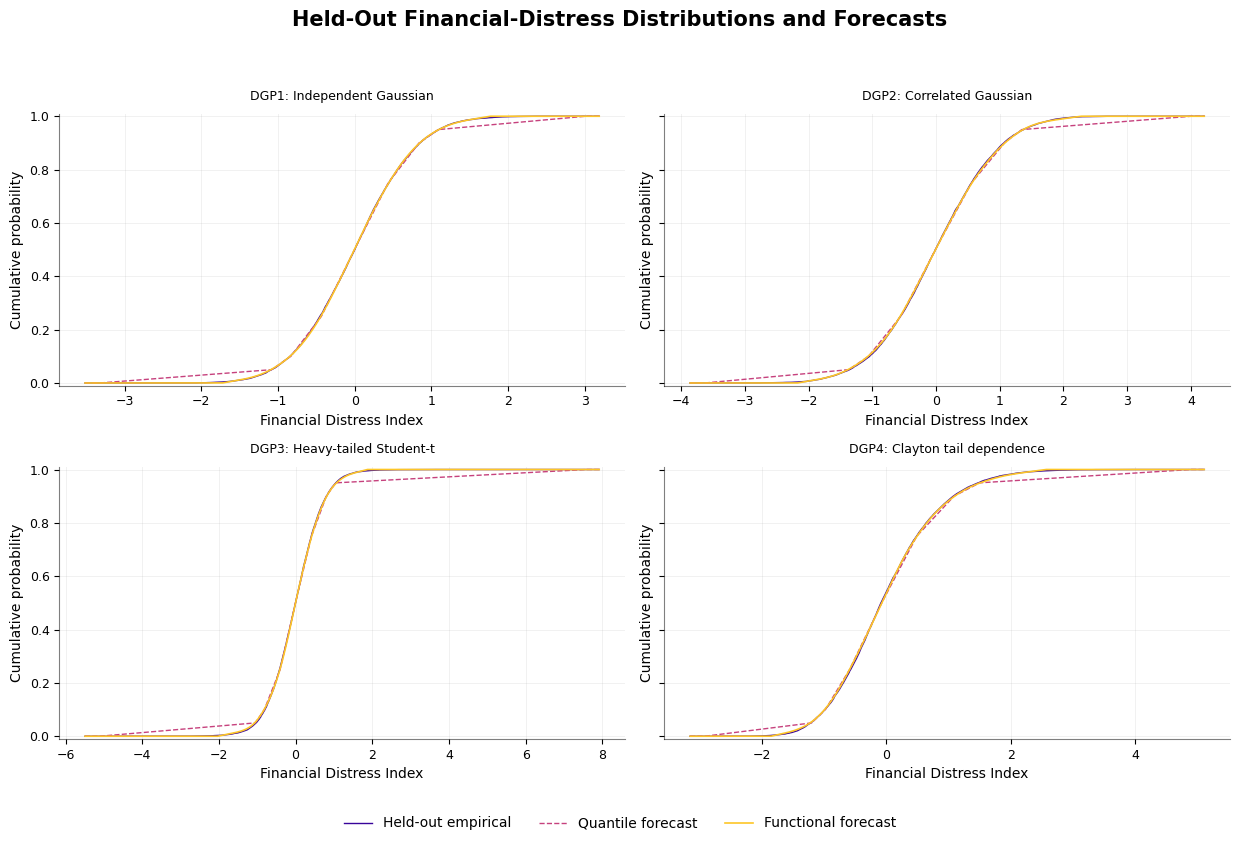

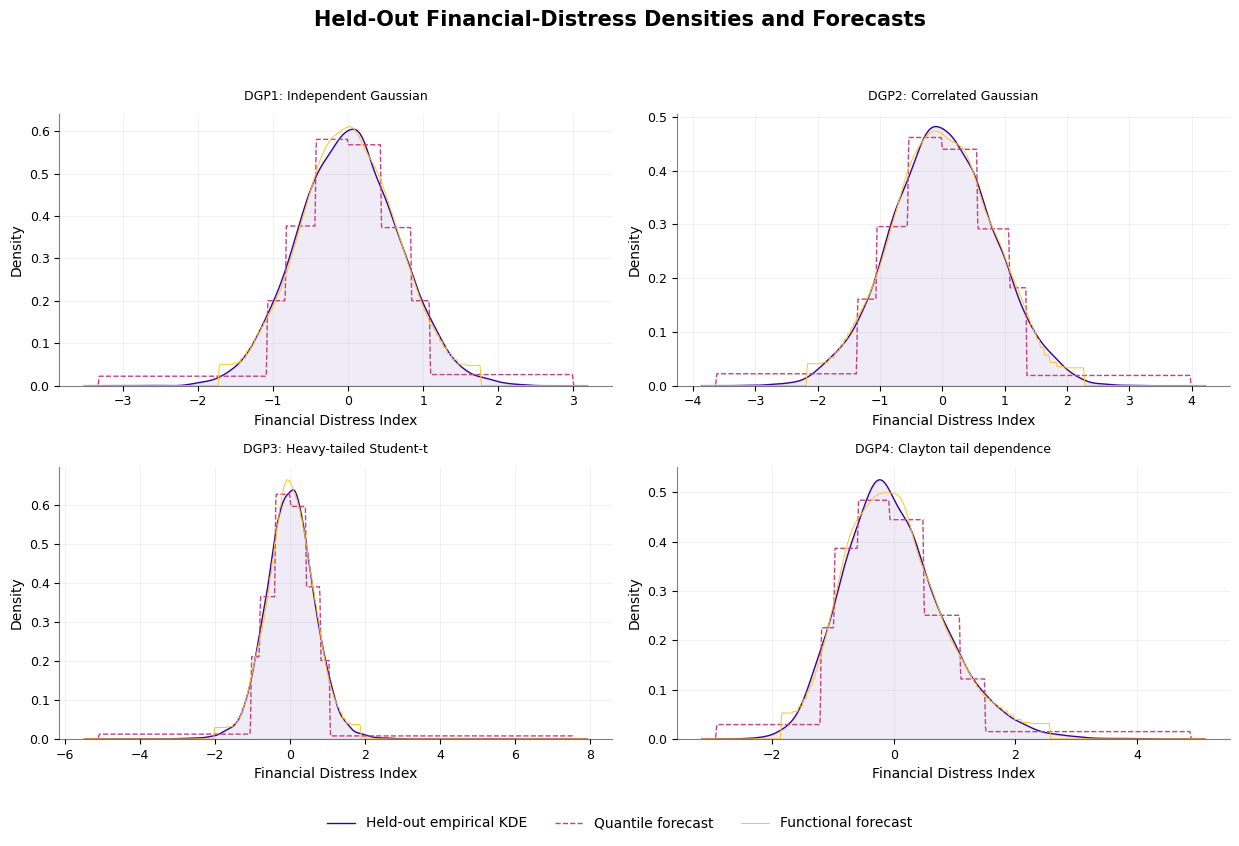

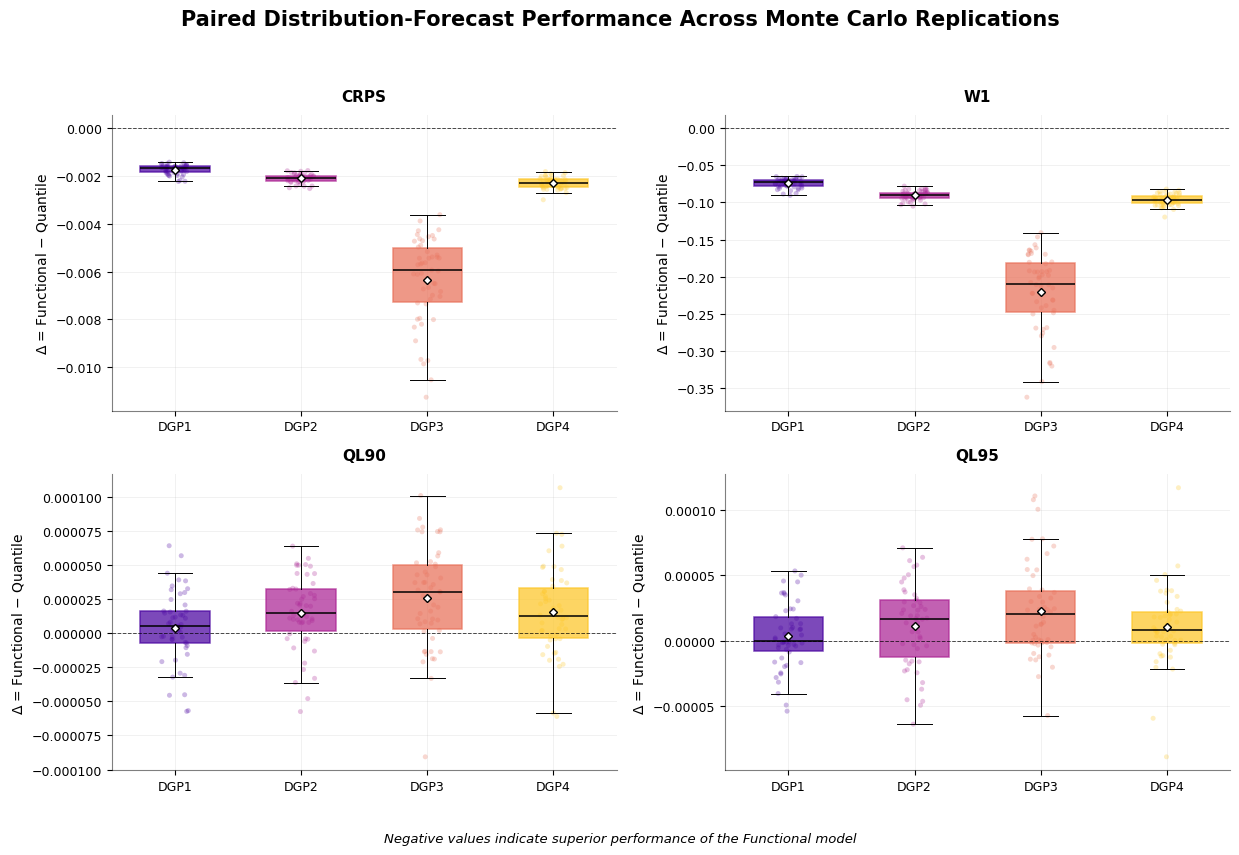

In [192]:
distribution_forecast_cdf_comparison(paired)
distribution_forecast_density_comparison(paired)
distribution_paired_differences(paired)